In [1]:
import torch

In [2]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Lambda

In [3]:
train_set = MNIST(root="data",
                  train=True,
                  download=True,
                  transform=ToTensor())
test_set = MNIST(root="data",
                 train=False,
                 download=True,
                 transform=ToTensor())

In [4]:
from torch.utils.data import DataLoader

In [18]:
train_dataloader = DataLoader(train_set, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size=64, shuffle=True)

In [19]:
from torch import nn

In [35]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.Dropout(0.3),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 10),
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.network(x)
    return logits

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.conv(x)
    logits = self.network(x)
    return logits

In [ ]:

model = NeuralNetwork().to(device)
print(model)


In [25]:
learning_rate, epochs, batch_size = 0.01, 10, 64
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [26]:
from os import pread
def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)

  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Forward pass
    pred = model(X)

    # Loss calculation
    loss = loss_fn(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)

  test_loss, correct = 0, 0
  model.eval()

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [27]:
for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.308519  [   64/60000]
loss: 0.340354  [ 6464/60000]
loss: 0.666129  [12864/60000]
loss: 0.409147  [19264/60000]
loss: 0.428094  [25664/60000]
loss: 0.417594  [32064/60000]
loss: 0.288883  [38464/60000]
loss: 0.340110  [44864/60000]
loss: 0.231444  [51264/60000]
loss: 0.750826  [57664/60000]
Test Error: 
 Accuracy: 93.0%, Avg loss: 0.252118 

Epoch 2
-------------------------------
loss: 0.499948  [   64/60000]
loss: 0.538411  [ 6464/60000]
loss: 0.356879  [12864/60000]
loss: 0.411695  [19264/60000]
loss: 0.392670  [25664/60000]
loss: 0.324565  [32064/60000]
loss: 0.402839  [38464/60000]
loss: 0.308770  [44864/60000]
loss: 0.282467  [51264/60000]
loss: 0.188529  [57664/60000]
Test Error: 
 Accuracy: 94.8%, Avg loss: 0.225882 

Epoch 3
-------------------------------
loss: 0.307064  [   64/60000]
loss: 1.630788  [ 6464/60000]
loss: 0.365928  [12864/60000]
loss: 0.237453  [19264/60000]
loss: 0.376487  [25664/60000]
loss: 0.444045  [32064/600

In [11]:
import matplotlib.pyplot as plt

In [12]:
test_features_batch, test_labels_batch = next(iter(test_dataloader))

Text(0.5, 1.0, 'True Label: 4')

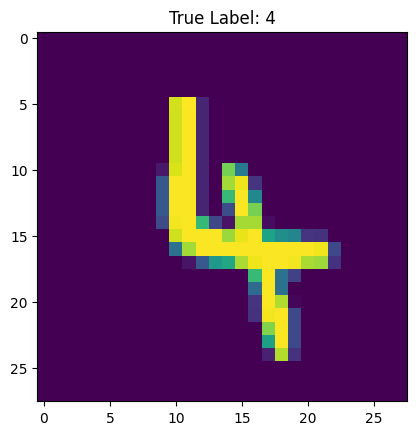

In [13]:
random_idx = torch.randint(0, len(test_features_batch), (1,)).item()

test_feature = test_features_batch[0]
test_label = test_labels_batch[0]

plt.imshow(test_feature.squeeze())
plt.title(f"True Label: {test_label}")

In [14]:
test_feature = test_feature.to(device)

In [15]:
prediction = model(test_feature)
print(f"Predicted Label: {prediction.argmax()}")

Predicted Label: 4


In [36]:
cnn = CNN().to(device)
print(cnn)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [37]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

In [38]:
for e in range(epochs):
    print(f"Epoch {e+1}\n-------------------------------")
    train_loop(train_dataloader, cnn, loss_fn, optimizer)
    test_loop(test_dataloader, cnn, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.310718  [   64/60000]
loss: 0.152987  [ 6464/60000]
loss: 0.221893  [12864/60000]
loss: 0.074562  [19264/60000]
loss: 0.099488  [25664/60000]
loss: 0.133952  [32064/60000]
loss: 0.053523  [38464/60000]
loss: 0.050822  [44864/60000]
loss: 0.042725  [51264/60000]
loss: 0.030176  [57664/60000]
Test Error: 
 Accuracy: 98.2%, Avg loss: 0.051188 

Epoch 2
-------------------------------
loss: 0.020823  [   64/60000]
loss: 0.037223  [ 6464/60000]
loss: 0.114944  [12864/60000]
loss: 0.036786  [19264/60000]
loss: 0.016519  [25664/60000]
loss: 0.249305  [32064/60000]
loss: 0.035501  [38464/60000]
loss: 0.028063  [44864/60000]
loss: 0.016528  [51264/60000]
loss: 0.081585  [57664/60000]
Test Error: 
 Accuracy: 98.9%, Avg loss: 0.035480 

Epoch 3
-------------------------------
loss: 0.018600  [   64/60000]
loss: 0.028304  [ 6464/60000]
loss: 0.025556  [12864/60000]
loss: 0.028012  [19264/60000]
loss: 0.078042  [25664/60000]
loss: 0.088374  [32064/600